,Unnamed: 0,ligand_id,tar_protein,tar_chain,src_protein,src_chain,cath_degree,src_ligand_n_atoms,tar_ligand_n_atoms,src_ligand,tar_ligand,ligand_rmsd,embedding_similarity,corr_rmsd,entropy,atom_type_fraction,radius_of_gyration,normalized_embedding_similarity,perplexity,radius_of_gyration_ang
0,0,FUC,2nzy,C,2ygq,A,0,10,10,FUC,FUC,32.382908,2.587511,1.659309,0.694879,0.586851,1.453478,0.621498,64.285995,9.990757
1,1,FE,6l3w,A,6rxn,A,0,1,1,FE,FE,0.963144,1.875859,1.558363,0.732558,0.410690,0.893040,0.427391,80.567415,6.718587
2,2,FE2,1ey2,A,4oj8,B,0,1,1,FE2,FE2,1.421442,2.430025,1.475860,0.682439,0.789890,1.039410,0.594311,59.668884,6.934730
3,3,SO3,1yt8,A,2vq2,A,0,4,4,SO3,SO3,16.105282,2.512157,1.690098,0.701941,0.936209,1.162385,0.597329,67.064370,8.126252
4,4,BHO,2atj,A,2boy,A,0,10,10,BHO,BHO,10.604116,2.124855,1.579942,0.707259,0.879589,1.262838,0.501439,69.235791,8.941763
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2308,2308,UDP,3hbn,A,7bv3,B,4,25,25,UDP,UDP,1.388550,4.022168,0.695930,0.787226,0.978143,0.790253,0.852761,111.791961,6.777562
2309,2309,COA,1cm0,A,1yvk,A,4,48,48,COA,COA,4.076278,4.547074,0.588470,0.826497,0.971628,0.749519,0.918243,141.447403,7.062589
2310,2310,FE,4ffk,A,8avl,A,4,1,1,FE,FE,0.051382,4.643147,0.337960,0.890002,0.999186,0.806827,0.870740,206.937007,8.852357
2311,2311,FAD,2dki,A,5xhu,A,4,53,53,FAD,FAD,2.601433,4.701769,0.535980,0.856219,0.992556,0.702531,0.916524,169.017606,7.108558


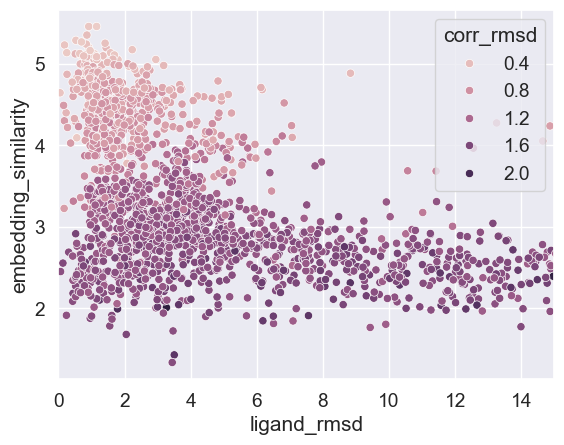

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import matplotlib.pyplot as plt

# table_results = 'per_sample_results_9-87099.csv'
table_results = 'baseline.csv'
checkpoint = 'baseline-embed01-ligand5-corr1-recycle4-radius05-sched-corr2/'

path2table = os.path.join('../plots/', table_results)
path2checkpoint = os.path.join('../checkpoints/',checkpoint)

table = pd.read_csv(path2table)

table['normalized_embedding_similarity'] = table['embedding_similarity'] / (table['entropy'] * np.log(400) )
table['perplexity'] = table['entropy'].map(lambda x: np.exp (x * np.log(400)) )
table['radius_of_gyration_ang'] = table['radius_of_gyration'] * 1.3 * table['perplexity']**0.4
table['tar_ligand_n_atoms'] = table['tar_ligand_n_atoms'].map(lambda x: int(x[1:-1].split(',')[0]))
table['src_ligand_n_atoms'] = table['src_ligand_n_atoms'].map(lambda x: int(x[1:-1].split(',')[0]))


sns.scatterplot(data=table,x='ligand_rmsd',y='embedding_similarity',
                hue='corr_rmsd')
plt.xlim([0,15])
display(table)

In [58]:
from sklearn.model_selection import GroupKFold,GridSearchCV
from sklearn.ensemble import HistGradientBoostingRegressor
from scipy.stats import spearmanr
from sklearn.metrics import make_scorer
         


# features = ['normalized_embedding_similarity','corr_rmsd','radius_of_gyration','perplexity']
features = ['normalized_embedding_similarity','corr_rmsd','radius_of_gyration_ang','perplexity']
monotonic_constraint = np.array([-1,1,1,-1])
target = 'ligand_rmsd'
target_cutoff = 10.


X = table[features]
y = table[target].map(lambda x: np.clip(x,0,target_cutoff))
groups = table['ligand_id'] # To avoid overfitting
stratify=table['cath_degree']==4. # To stratify by performance.

cross_val_split = GroupKFold(n_splits=5,shuffle=True,random_state=5)
cv_generator = cross_val_split.split(X=X, y=y, groups=groups)

regressor = HistGradientBoostingRegressor(loss='absolute_error',
                                          interaction_cst='no_interactions',
                                          monotonic_cst=monotonic_constraint)


param_grid = {
    'l2_regularization': np.logspace(-2,0,num=5), # The smallest regularization is quite high to make sure that the prediction is smooth.
    'learning_rate': [0.025, 0.05,0.075,0.1],
    'max_iter': [50,100,200,300,400,500],
    'max_leaf_nodes': [7,15,31],
}


def spearman_scorer(y_true, y_pred):
    """
    Wraps scipy.stats.spearmanr to return only the correlation coefficient.
    """
    # spearmanr returns (correlation, pvalue)
    score, _ = spearmanr(y_true, y_pred)
    return score

# Create the scorer object
# greater_is_better=True because a higher correlation (closer to 1.0) is better
spearman_rank_scorer = make_scorer(spearman_scorer, greater_is_better=True)

grid_search = GridSearchCV(estimator=regressor,param_grid=param_grid,cv=cv_generator,scoring=spearman_rank_scorer,#scoring='neg_mean_absolute_error',
                           n_jobs=-1,refit=True)

grid_search.fit(X,y)

regressor = grid_search.best_estimator_

print(grid_search.best_params_)

/opt/miniconda3/envs/localign_infer3/lib/python3.10/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/opt/miniconda3/envs/localign_infer3/lib/python3.10/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/opt/miniconda3/envs/localign_infer3/lib/python3.10/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain fr

{'l2_regularization': 0.1, 'learning_rate': 0.05, 'max_iter': 500, 'max_leaf_nodes': 15}


/opt/miniconda3/envs/localign_infer3/lib/python3.10/site-packages/sklearn/model_selection/_split.py:86: UserWarning: The groups parameter is ignored by KFold
  warnings.warn(


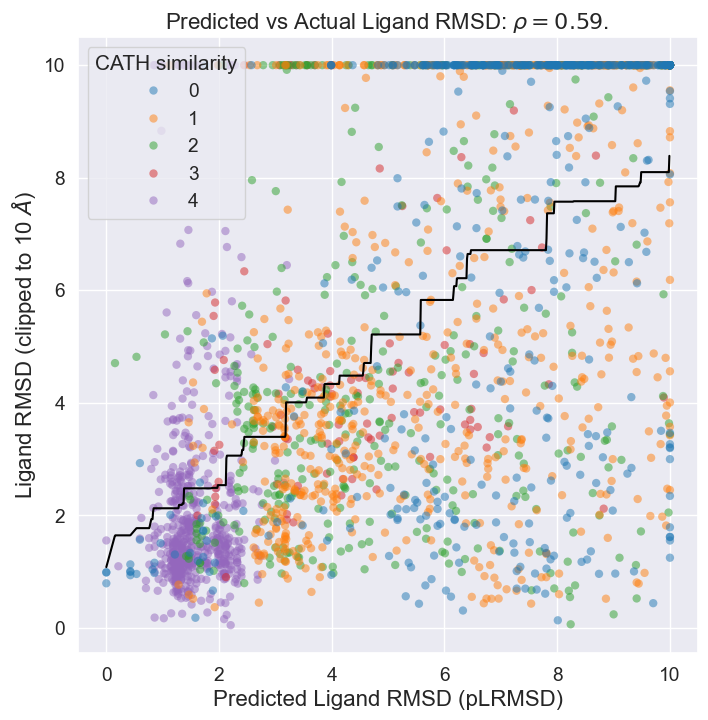

In [59]:
from sklearn.model_selection import cross_val_predict
import seaborn as sns
from sklearn.isotonic import IsotonicRegression


plots_folder = '../plots/calibration_model/baseline/'
os.makedirs(plots_folder,exist_ok=True)

figsize = 8
fs = figsize * 2

cross_val_split = GroupKFold(n_splits=5,shuffle=True,random_state=5)
cv_generator = cross_val_split.split(X=X, y=y, groups=groups)

regressor_cv = HistGradientBoostingRegressor(loss='absolute_error',
                                          interaction_cst='no_interactions',
                                          monotonic_cst=monotonic_constraint,
                                          **grid_search.best_params_
                                          )


cv_predictions = cross_val_predict(estimator=regressor_cv,X=X,y=y,groups=groups)

new_table = pd.DataFrame({'LRMSD': y, 'pLRMSD': np.clip(cv_predictions,0,10.),
             'CATH similarity':table['cath_degree'],
             })
new_table = new_table.sort_values(by='CATH similarity',ascending=False)


isotonic_fit = IsotonicRegression()
isotonic_fit.fit( new_table['pLRMSD'], new_table['LRMSD'] )

x_trend = np.arange(0,10,0.01)
y_trend = isotonic_fit.predict(x_trend[:,None])

fig, ax = plt.subplots(figsize=(figsize,figsize))
sns.set(font_scale=1.25)
sns.scatterplot(data=new_table,x='pLRMSD',y='LRMSD',
                hue='CATH similarity', palette='tab10',alpha=0.5,edgecolor="none")

r,_ = spearmanr( new_table['pLRMSD'],new_table['LRMSD'])
ax.plot(x_trend,y_trend,c='black')
ax.set_title(f'Predicted vs Actual Ligand RMSD: $\\rho={r:.2f}$. ',fontsize=fs)
ax.set_xlabel('Predicted Ligand RMSD (pLRMSD)',fontsize=fs)
ax.set_ylabel('Ligand RMSD (clipped to 10 $\AA$)',fontsize=fs)


plt.savefig(os.path.join(plots_folder, 'pLRMSD_vs_LRMSD.png'),dpi=300)



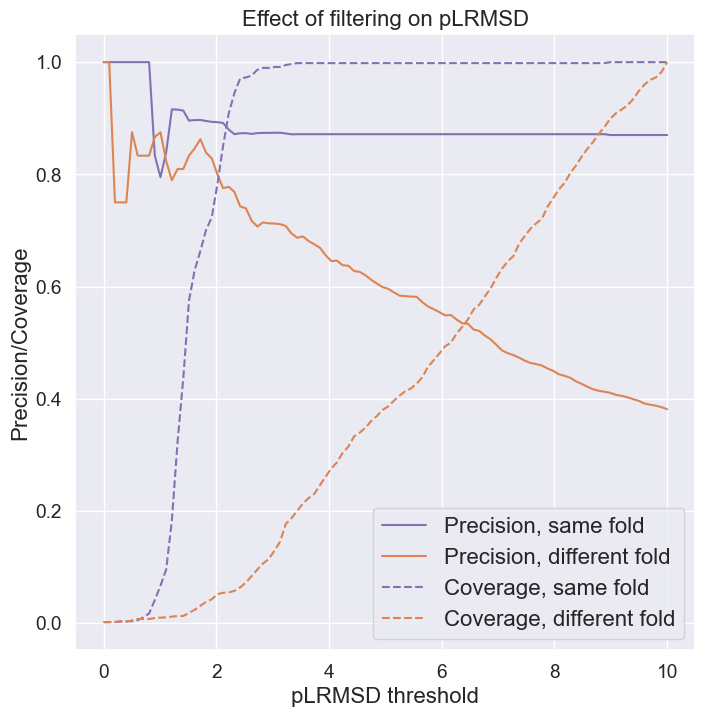

In [ ]:
# table['pLRMSD'] = cv_predictions

# table['Success'] = (table['corr_rmsd']<=2.0) & (table['atom_type_fraction']>=0.5) & (table['ligand_rmsd']<=4.0)

# nthresholds = 100

# thresholds = np.arange(nthresholds) / (nthresholds-1) * 10.

# count_above_threshold = np.zeros([nthresholds,2])
# successful_above_threshold = np.zeros([nthresholds,2])

# for k,threshold in enumerate(thresholds):
#     count_above_threshold[k,0] =  ( (table['pLRMSD'] <= threshold) & (table['cath_degree']==4) ).sum()
#     count_above_threshold[k,1] =  ( (table['pLRMSD'] <= threshold) & (table['cath_degree'] < 4) ).sum()
#     successful_above_threshold[k,0] =  ( table['Success'] &  (table['pLRMSD'] <= threshold) & (table['cath_degree']==4) ).sum()
#     successful_above_threshold[k,1] =  ( table['Success'] &  (table['pLRMSD'] <= threshold) & (table['cath_degree'] < 4) ).sum()    


# precision = successful_above_threshold/count_above_threshold
# recall = count_above_threshold/count_above_threshold.max(0,keepdims=True)


fig, ax = plt.subplots(figsize=(figsize,figsize))
ax.plot(thresholds,precision[:,0],color='C4',linestyle='-',label='Precision, same fold')
ax.plot(thresholds,precision[:,1],color='C1',linestyle='-',label='Precision, different fold')
ax.plot(thresholds,recall[:,0],color='C4',linestyle='--',label='Recall, same fold')
ax.plot(thresholds,recall[:,1],color='C1',linestyle='--',label='Recall, different fold')
# ax.grid()
ax.set_xlabel('pLRMSD threshold',fontsize=fs)
ax.set_ylabel('Precision/Recall',fontsize=fs)
ax.legend(fontsize=fs)
ax.set_title('Effect of filtering on pLRMSD',fontsize=fs)
plt.savefig(os.path.join(plots_folder, 'filtering_pLRMSD.png'),dpi=300)

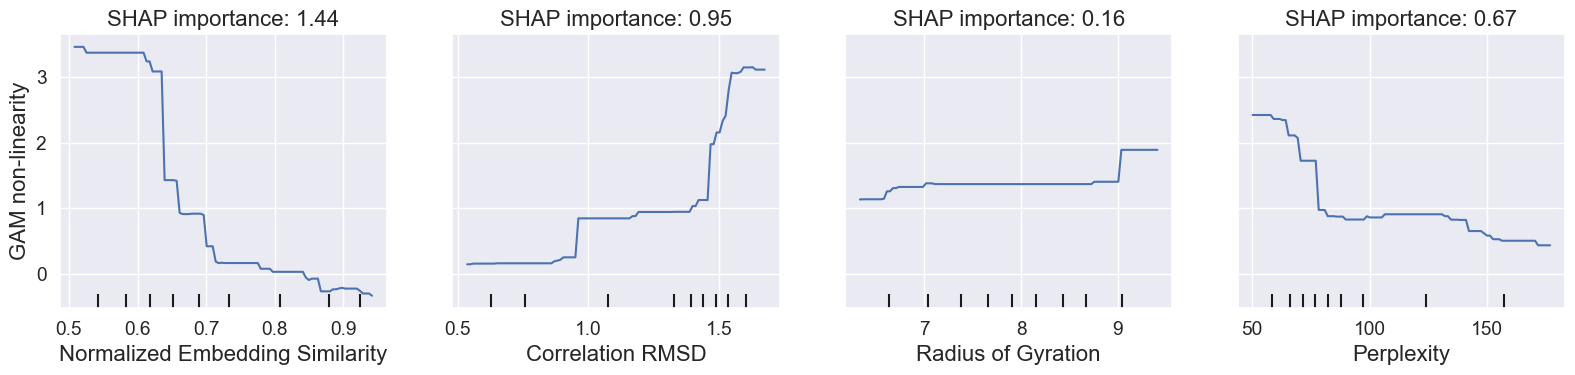

In [61]:
from sklearn.inspection import PartialDependenceDisplay
import shap
explainer = shap.TreeExplainer(model=regressor)
shap_values = explainer.shap_values(X)
feature_importances = np.abs(shap_values).mean(0)


fig, ax  = plt.subplots(figsize=(2*figsize, 0.5* figsize))
display_=PartialDependenceDisplay.from_estimator(regressor,X,features=features,ax=ax,n_cols=4)

names = ['Normalized Embedding Similarity',
         'Correlation RMSD',
         'Radius of Gyration',
         'Perplexity']

for k,ax_ in enumerate(display_.axes_[0]):
    if k == 0:
        ax_.set_ylabel('GAM non-linearity',fontsize=fs)
    ax_.set_xlabel( names[k], fontsize=fs)
    ax_.set_title(f'SHAP importance: {feature_importances[k]:.2f}',fontsize=fs)
plt.tight_layout()
plt.savefig(os.path.join(plots_folder, 'GAM_pLRMSD.png'),dpi=300)



In [62]:
from sklearn.model_selection import GroupKFold,GridSearchCV
from sklearn.ensemble import HistGradientBoostingRegressor
from scipy.stats import spearmanr
from sklearn.metrics import make_scorer

features_baseline = ['tar_ligand_n_atoms']
monotonic_constraint = np.array([1])
target = 'ligand_rmsd'
target_cutoff = 10.
quantile = 0.2

X = table[features_baseline]
y = table[target].map(lambda x: np.clip(x,0,target_cutoff))
groups = table['ligand_id'] # To avoid overfitting
stratify=table['cath_degree']==4. # To stratify by performance.

cross_val_split = GroupKFold(n_splits=5,shuffle=True,random_state=5)
cv_generator = cross_val_split.split(X=X, y=y, groups=groups)

regressor_baseline = HistGradientBoostingRegressor(loss='quantile',quantile = quantile,
                                          monotonic_cst=monotonic_constraint,
                                          max_bins=128)


param_grid = {
    'l2_regularization': np.logspace(-2,0,num=5), # The smallest regularization is quite high to make sure that the prediction is smooth.
    'learning_rate': [0.025, 0.05,0.075,0.1],
    'max_iter': [50,100,200,300,400,500],
    'max_leaf_nodes': [7,15,31],
}

# param_grid = {
#     'l2_regularization': np.logspace(-2,0,num=2), # The smallest regularization is quite high to make sure that the prediction is smooth.
#     'learning_rate': [0.025, 0.1],
#     'max_iter': [100,200],
#     'max_leaf_nodes': [7,15,31],
# }

def spearman_scorer(y_true, y_pred):
    """
    Wraps scipy.stats.spearmanr to return only the correlation coefficient.
    """
    # spearmanr returns (correlation, pvalue)
    score, _ = spearmanr(y_true, y_pred)
    return score
# Create the scorer object
# greater_is_better=True because a higher correlation (closer to 1.0) is better
spearman_rank_scorer = make_scorer(spearman_scorer, greater_is_better=True)


grid_search_baseline = GridSearchCV(estimator=regressor_baseline,param_grid=param_grid,cv=cv_generator,
                                    scoring=spearman_rank_scorer,
                           n_jobs=-1,refit=True)

grid_search_baseline.fit(X,y)

regressor_baseline = grid_search_baseline.best_estimator_

print(grid_search_baseline.best_params_)




{'l2_regularization': 0.01, 'learning_rate': 0.025, 'max_iter': 50, 'max_leaf_nodes': 7}


/opt/miniconda3/envs/localign_infer3/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but HistGradientBoostingRegressor was fitted with feature names
  warnings.warn(


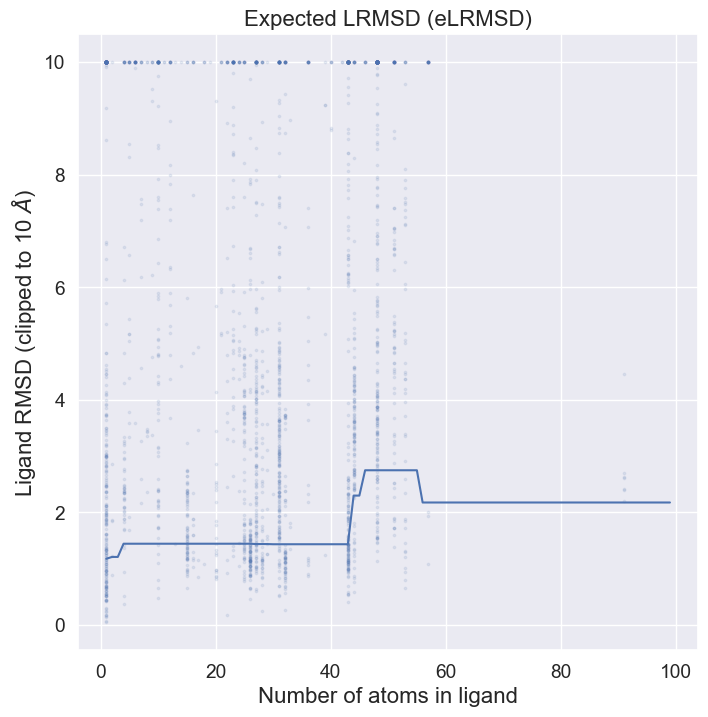

In [63]:
fig, ax = plt.subplots(figsize=(figsize,figsize))
xtest = np.arange(1,100)[:,None]
ytest = regressor_baseline.predict(xtest)
plt.plot(xtest,ytest)
plt.scatter(X,y,alpha=0.1,s=3)
plt.xlabel('Number of atoms in ligand',fontsize=fs)
ax.set_ylabel('Ligand RMSD (clipped to 10 $\AA$)',fontsize=fs)
plt.title('Expected LRMSD (eLRMSD)',fontsize=fs)
plt.savefig(os.path.join(plots_folder, 'eLRMSD.png'),dpi=300)
plt.show()

In [64]:
import pickle
pickle.dump(regressor, open(os.path.join(path2checkpoint,'calibration_model.pkl'),'wb') )
pickle.dump(regressor_baseline, open(os.path.join(path2checkpoint,'ligand_calibration_model.pkl'),'wb') )

In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import pickle
import matplotlib.pyplot as plt

checkpoint = 'baseline-embed01-ligand5-corr1-recycle4-radius05-sched-corr2/'

path2checkpoint = os.path.join('../checkpoints/',checkpoint)

regressor = pickle.load(open(os.path.join(path2checkpoint,'calibration_model.pkl'),'rb'))
regressor_baseline = pickle.load(open(os.path.join(path2checkpoint,'ligand_calibration_model.pkl'),'rb'))

example = '8vc8'
table = pd.read_csv(f'/Users/jerometubiana/Downloads/inference_results_{example}.csv')

database = pd.read_csv('/Users/jerometubiana/Downloads/biolip2_nr_database_with_motif_n_ligand_atoms.csv')
# database = pd.read_csv('/Users/jerometubiana/GitHub/LocAlign/example_inputs/biolip2_nr_with_motif_database.csv')

database['index'] = database['tar_protein'] + database['tar_chain']
database['tar_ligand_n_atoms'] = database['n_ligand_atoms'].map(lambda x: float(x[1:-1].split(',')[0] if len(x)>2 else np.nan ))


# database['tar_ligand_n_atoms'] = np.random.randint(0,100,size=len(database))
database = database[['index','tar_ligand_n_atoms']]
database = database.set_index(keys='index')

table['index'] = table['tar_protein'] + table['tar_chain']
table = table.set_index(keys='index')

table = pd.merge(left=table,right=database,left_index=True,right_index=True)

# display(table)

features = ['attribute_similarity','correspondence_rmsd','radius_gyration','perplexity']
# features = ['attribute_similarity','correspondence_rmsd','_radius','perplexity']

table['pLRMSD'] = regressor.predict(table[features].to_numpy())

table['expected_LRMSD'] = regressor_baseline.predict( table['tar_ligand_n_atoms'].to_numpy()[:,None] )

# table['expected_LRMSD'] = 1.2 * (table['tar_ligand_n_atoms'])**(0.4)

table['normalized_pLRMSD'] = table['pLRMSD'] / table['expected_LRMSD']
table = table.sort_values(by='normalized_pLRMSD',ascending=True)
display(table)





/opt/miniconda3/envs/localign_infer3/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but HistGradientBoostingRegressor was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/localign_infer3/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but HistGradientBoostingRegressor was fitted with feature names
  warnings.warn(


,tar_protein,tar_chain,tar_motif,src_protein,src_chain,src_motif,cath_degree,Ligand RMSD,ligand,tar_ligand,...,correspondence_rmsd,radius_gyration,_embedding,_gap,_corr_rmsd,_radius,output_folder,tar_ligand_n_atoms,expected_LRMSD,normalized_pLRMSD
index,,,,,,,,,,,,,,,,,,,,,
8vc8A,8vc8,A,"[33, 34, 36, 37, 81, 88, 98, 99, 101, 102, 137...",8vc8,A,NaN,-1,0.0,HEM,HEM,...,0.068,9.306,4.785,0.919,0.068,0.793,inference_slurm_2112/database_search_8vc8_A_20...,43.0,1.435647,1.077847
8e7sH,8e7s,H,"[48, 51, 52, 55]",8vc8,A,NaN,-1,0.0,CDL,CDL,...,0.901,4.835,2.127,0.671,0.901,0.749,inference_slurm_2112/database_search_8vc8_A_20...,53.0,2.749831,1.629195
3agaA,3aga,A,"[121, 135, 137, 139, 141, 154, 156, 207, 209, ...",8vc8,A,NaN,-1,0.0,RCC,RCC,...,1.328,8.507,2.841,0.661,1.328,1.347,NaN,46.0,2.749831,1.668751
7y7bR,7y7b,R,"[119, 122, 123, 126, 129, 201, 204]",8vc8,A,NaN,-1,0.0,CLA,CLA,...,1.125,5.445,2.158,0.658,1.125,0.869,inference_slurm_2112/database_search_8vc8_A_20...,55.0,2.749831,1.859052
6cyyA,6cyy,A,"[363, 364, 443, 444, 446, 447, 450, 452, 455, ...",8vc8,A,NaN,-1,0.0,SF4,SF4,...,1.077,5.329,2.292,0.648,1.077,0.871,inference_slurm_2112/database_search_8vc8_A_20...,48.0,2.749831,1.860419
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2fiyA,2fiy,A,"[185, 188, 211, 214, 225, 228, 256, 259]",8vc8,A,NaN,-1,0.0,FE,FE,...,1.731,10.153,1.650,0.604,1.731,1.842,NaN,1.0,1.178371,10.551231
4lw9A,4lw9,A,"[44, 48, 139, 140, 141, 142, 144, 319]",8vc8,A,NaN,-1,0.0,ZN,ZN,...,1.773,10.295,1.621,0.593,1.773,1.910,NaN,1.0,1.178371,10.551231
2vyoA,2vyo,A,"[25, 49, 101, 176, 1226, 1227, 2007, 2022, 202...",8vc8,A,NaN,-1,0.0,CA,CA,...,1.781,10.434,1.204,0.560,1.781,2.117,NaN,1.0,1.178371,10.551231


In [10]:
'''
from sklearn.model_selection import train_test_split
from sklearn.ensemble import HistGradientBoostingRegressor

table['normalized_embedding_similarity'] = table['embedding_similarity'] / (table['entropy'] * np.log(400) )
table['perplexity'] = table['entropy'].map(lambda x: np.exp (x * np.log(400)) )
table['radius_of_gyration_ang'] = table['radius_of_gyration'] * 1.3 * table['perplexity']**0.4

# features = ['normalized_embedding_similarity','corr_rmsd','radius_of_gyration_ang','perplexity',
#             'tar_ligand_n_atoms']


# features = ['normalized_embedding_similarity','corr_rmsd','radius_of_gyration','perplexity',
            # 'tar_ligand_n_atoms']

features = ['normalized_embedding_similarity','corr_rmsd','radius_of_gyration','perplexity']

# features = ['normalized_embedding_similarity','corr_rmsd','perplexity']

# features = ['normalized_embedding_similarity','corr_rmsd','perplexity','tar_ligand_n_atoms']

# features = ['embedding_similarity','corr_rmsd','radius_of_gyration','entropy']
# features = ['normalized_embedding_similarity','corr_rmsd','radius_of_gyration','perplexity']
# features = ['normalized_embedding_similarity','corr_rmsd','perplexity']

target = 'ligand_rmsd'

monotonic_cst=np.array([-1,1,1,-1,1])
# monotonic_cst=np.array([-1,1,1,-1])
# monotonic_cst=np.array([-1,1,-1])
# monotonic_cst=np.array([-1,1,-1,1])

X = table[features]
y = table[target].map(lambda x: np.clip(x,0,10))

#thresholds = np.array([0.5, 1.,2.,4.])
# y = table[target].map( lambda x: (x>=thresholds).sum() )

z = table['cath_degree']
index = table['Unnamed: 0']

X_train,X_test,y_train,y_test,z_train,z_test,index_train,index_test = train_test_split(X,y,z,index)

regressor = HistGradientBoostingRegressor(loss='absolute_error',
                                          monotonic_cst=monotonic_cst,max_features=0.2,max_iter=200,
                                          interaction_cst='no_interactions')


regressor.fit(X_train,y_train)

predictions = regressor.predict(X_test)

fig, ax = plt.subplots(figsize=(12,12))
plt.scatter(y_test,predictions,c=z_test )
# sns.swarmplot(x=y_test,y=predictions,hue=z_test); 
print(np.corrcoef(y_test,predictions)[0,1])
plt.show()
'''

"\nfrom sklearn.model_selection import train_test_split\nfrom sklearn.ensemble import HistGradientBoostingRegressor\n\ntable['normalized_embedding_similarity'] = table['embedding_similarity'] / (table['entropy'] * np.log(400) )\ntable['perplexity'] = table['entropy'].map(lambda x: np.exp (x * np.log(400)) )\ntable['radius_of_gyration_ang'] = table['radius_of_gyration'] * 1.3 * table['perplexity']**0.4\n\n# features = ['normalized_embedding_similarity','corr_rmsd','radius_of_gyration_ang','perplexity',\n#             'tar_ligand_n_atoms']\n\n\n# features = ['normalized_embedding_similarity','corr_rmsd','radius_of_gyration','perplexity',\n            # 'tar_ligand_n_atoms']\n\nfeatures = ['normalized_embedding_similarity','corr_rmsd','radius_of_gyration','perplexity']\n\n# features = ['normalized_embedding_similarity','corr_rmsd','perplexity']\n\n# features = ['normalized_embedding_similarity','corr_rmsd','perplexity','tar_ligand_n_atoms']\n\n# features = ['embedding_similarity','corr_rm